<a href="https://colab.research.google.com/github/adriatek/waymo-scene-verifier/blob/main/Waymo_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install waymo-open-dataset-tf-2-12-0==1.6.7 --no-deps
!pip install protobuf==3.20.0

from waymo_open_dataset import dataset_pb2 as open_dataset
print("imports fine, we're in business")

  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.0 which is incompatible.
wandb 0.28.0 requires protobuf!=5.28.0,!=5.29.0,<8,>4.21.0, but you have protobuf 3.20.0 which is incompatible.
google-cloud-spanner 3.68.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.0 which is incompatible.
proto-plus 1.28.1 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.0 which is incompatible.
google-cloud-dataproc 5.28.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.0 which is incompatible.
googleapis-common-proto

imports fine, we're in business


In [9]:
from google.colab import auth
auth.authenticate_user()

In [10]:
!gsutil ls gs://waymo_open_dataset_v_1_4_2/individual_files/training/ | head -5

gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10017090168044687777_6380_000_6400_000_with_camera_labels.tfrecord
gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10023947602400723454_1120_000_1140_000_with_camera_labels.tfrecord
gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-1005081002024129653_5313_150_5333_150_with_camera_labels.tfrecord
gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10061305430875486848_1080_000_1100_000_with_camera_labels.tfrecord
gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10072140764565668044_4060_000_4080_000_with_camera_labels.tfrecord
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


In [11]:
!gsutil cp gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10017090168044687777_6380_000_6400_000_with_camera_labels.tfrecord /content/segment.tfrecord

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://waymo_open_dataset_v_1_4_2/individual_files/training/segment-10017090168044687777_6380_000_6400_000_with_camera_labels.tfrecord...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

| [1 files][  1.0 GiB/  1.0 GiB]   37.1 MiB/s                                   
Operation completed over 1 objects/1.0 GiB.                                      


In [18]:
!pip install "protobuf==5.29.1"

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1


In [1]:
#parsing first frame
import tensorflow as tf
from waymo_open_dataset import dataset_pb2 as open_dataset

dataset = tf.data.TFRecordDataset('/content/segment.tfrecord', compression_type='')

frame = open_dataset.Frame()
for data in dataset:
  frame.ParseFromString(bytearray(data.numpy()))
  break #just the first frame today

print("Segment ID:", frame.context.name)
print("Time of day:", frame.context.stats.time_of_day)
print("Weather:", frame.context.stats.weather)
print("Location:", frame.context.stats.location)

Segment ID: 10017090168044687777_6380_000_6400_000
Time of day: Day
Weather: sunny
Location: location_sf


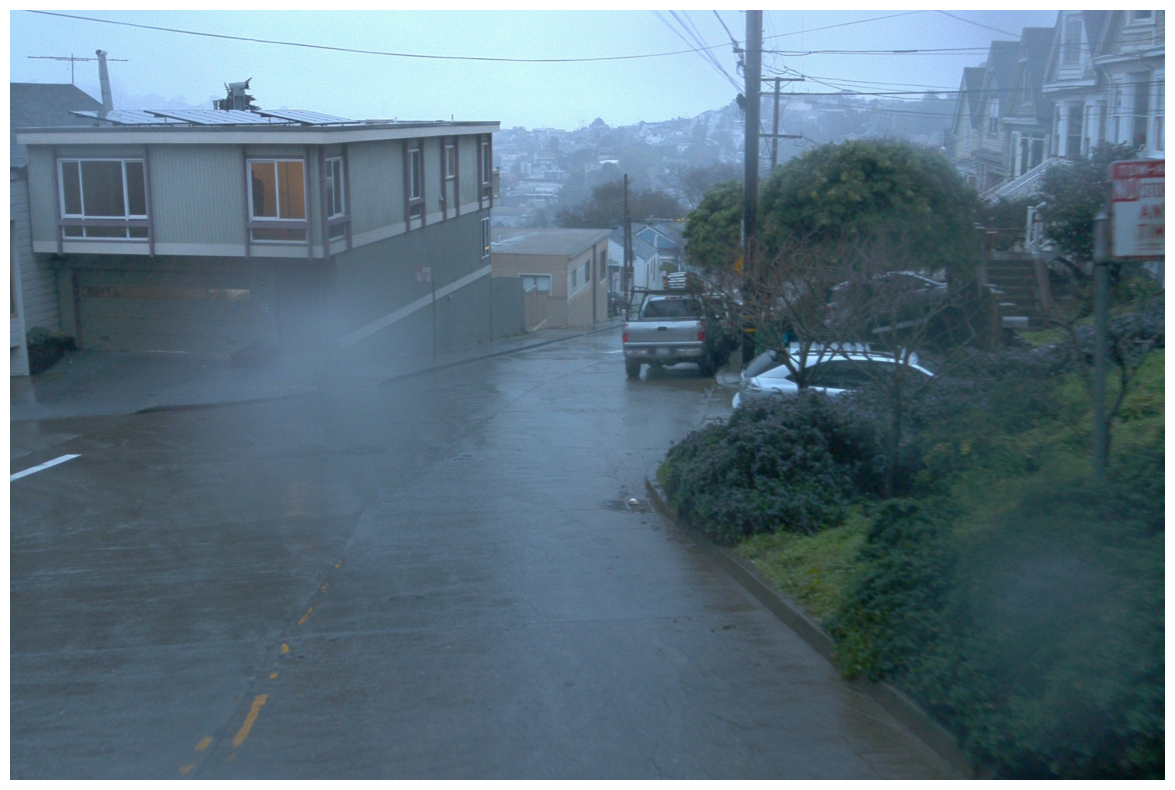

In [2]:
#what did the car see?
import matplotlib.pyplot as plt

img = frame.images[0]  # front camera
decoded = tf.image.decode_jpeg(img.image)

plt.figure(figsize=(15, 10))
plt.imshow(decoded)
plt.axis('off')
plt.show()

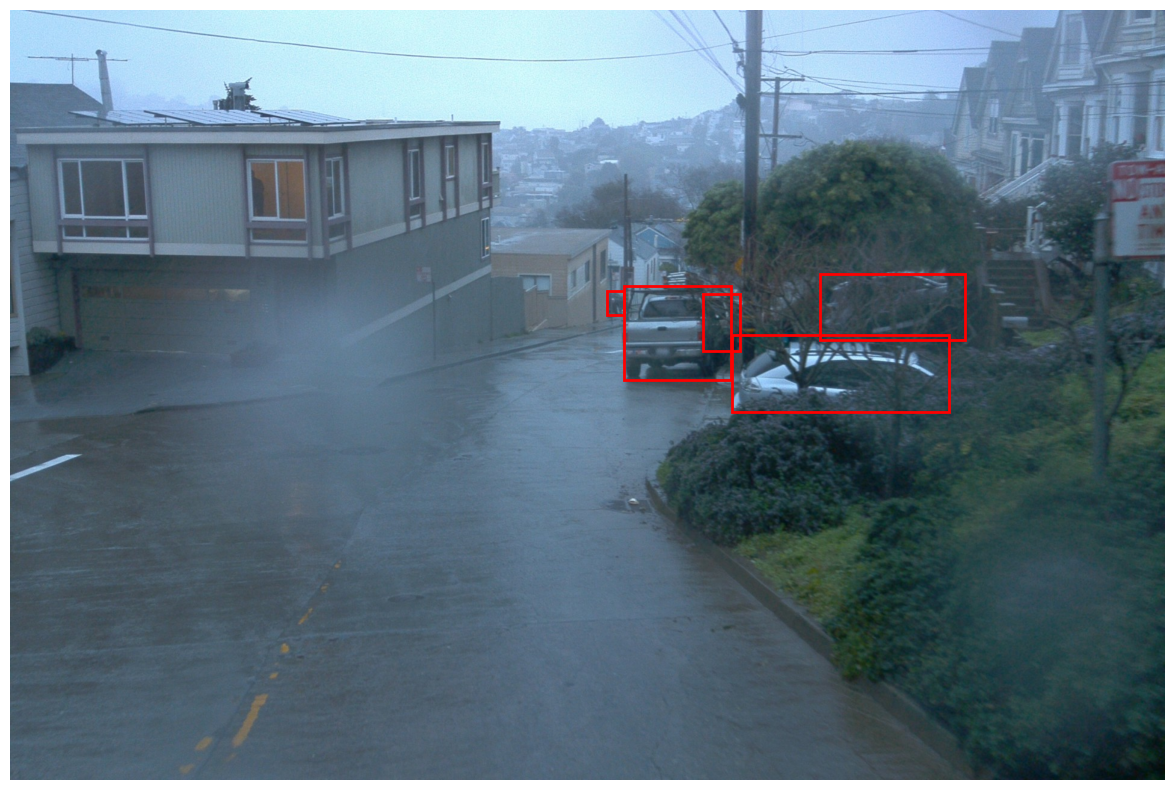

In [3]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(15,10))
ax.imshow(decoded)

#find the labels for this same camera
for camera_labels in frame.camera_labels:
  if camera_labels.name != img.name:
    continue
  for label in camera_labels.labels:
    rect = patches.Rectangle(
        (label.box.center_x - label.box.length / 2,
             label.box.center_y - label.box.width / 2),
            label.box.length, label.box.width,
            linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

ax.axis('off')
plt.show()

